# Chapter 1 problems

This notebook contains the problems from [Chapter 1 Data](https://minireference.com/static/excerpts/noBSstats_part1_preview.pdf#page=12)
in the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Figures setup
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={"figure.figsize": (5, 2)},
)
%config InlineBackend.figure_format = 'retina'

In [3]:
# Set pandas precision
pd.set_option("display.precision", 2)

In [4]:
# Simple float __repr__
import numpy as np
if int(np.__version__.split(".")[0]) >= 2:
    np.set_printoptions(legacy='1.25')

In [5]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory already exists.


### P1.1

Create a bar plot that
compares the mean `score`s for the `debate` and `lecture` groups in the
students dataset ([`datasets/students.csv`](https://noBSstats.com/datasets/students.csv)).
The height of each bar should show the mean `score` for each
`curriculum` type, with error bars indicating the standard deviation for
each group.

Hint: Use `sns.barplot` and set the required value for the `errorbar` option.

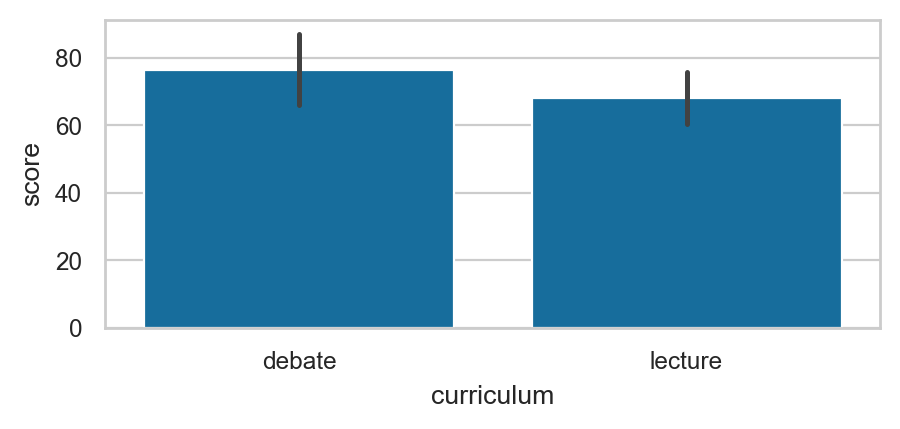

In [7]:
import pandas as pd
students = pd.read_csv("datasets/students.csv")

import seaborn as sns
sns.barplot(data=students, x="curriculum", y="score", errorbar="sd");

The above bar plot compares the mean `score`
between the `debate` and `lecture` curriculum variants.
The error bars stretch from $\textbf{mean} - \textbf{std}$
to $\textbf{mean} + \textbf{std}$ within each group,
and provide an idea of the data variability.

By default, the function `sns.barplot` uses the option `estimator="mean"`,
so it will represent the mean of each group as the height of the bars.
If we want the error bars to extend $\pm\mathbf{std}$,
we need to provide the option `errorbar="sd"` (short for standard deviation).

### P1.2

For each of the following sampling scenarios,
determine whether the results obtained will apply to the population as a whole.  
**a)** A researcher interested in the mobile usage among 18 year olds used the
national citizens registry to obtain a list of all 18 year olds in the
country, and randomly selected a sample of size $n=100$ from this list
to contact.  
**b)** A librarian is interested in the lending patterns of digital
vs print books for the users of her library. The librarian used the
library management system to extract checkout statistics for print books
and digital loans for all users of the library for the past five years.  
**c)** The library website administrator ran a survey to collect feedback on
the new library discovery tool from the student body. The survey
appeared on the website during the month of July and August.  
**d)** A university wants to estimate the proportion of students who have a
part-time job, so they ask a random sample of $n=60$ students from all
currently registered students.  
**e)** A researcher wants to estimate the
average screen time of teenagers in the country by running a survey on a
social media site and analyzing the responses of people who choose to
respond.

**a)** Yes, **b)** Yes, **c)** No, **d)** Yes, **e)** No.

See the book for the solutions.

### P1.3

A statistician working for the ministry of health is studying the sleep
quality and duration of family doctors in the country. In particular,
they are interested in the effectiveness of a new sleep tracking app.
For each of the studies described below, determine if it is
*experimental* or *observational* in nature, and whether it is performed
on a *representative* sample. Will the study results *generalize* to the
population of all doctors in the country? Does the study support a
*causal* conclusion?

**a)** The researcher uses the national doctors' registry to select $100$
doctors at random, and makes them fill out a survey about the number of
hours they sleep per night.

**b)** The researcher places a banner ad on the
central web portal that doctors use every day to communicate with their
patients. The ad asks doctors to volunteer for a sleep study, and
manages to recruit 200 volunteers. The researcher then randomly assigns
half of them to use a sleep tracking app and half to a control group
that receives some basic educational messaging about the importance of
sleep. 

**c)** The researcher selects 200 doctors at random from the national
doctors' registry, and randomly assigns them either to use the sleep
tracking app or to the control group (basic educational messaging).

**d)** The researcher sends a paper survey by mail to all family doctors that asks
them about the number of hours they sleep per night, and analyzed the
results of the doctors who replied.


Study **a)** is observational and uses a representative sample. The
doctors are randomly selected from the registry, so we can expect the
results to generalize to all family doctors in the country. Study **b)**
is experimental but uses a non-representative sample, since the sample
consists of volunteer respondents. The random assignment will allow the
researcher to make causal claims. Study **c)** is experimental and uses
a representative sample, so we can expect results to generalize. The
random assignment to the two groups supports causal inference. Study
**d)** is observational and uses a non-representative sample, so we
don't expect the results to generalize.

### P1.4
Classify the following variables according to their *level of measurement* subtype:
*nominal*, *ordinal*, *interval*, or *ratio*.  
**a)** Body temperature measured in $^\circ$C  
**b)** Sleep duration during one night measured in minutes  
**c)** Request priority level (low, medium, high, urgent)  
**d)** File size measured in megabytes  
**e)** Payment method used (cash, credit, debit, e-transfer)  
**f)** T-shirt size (XS, S, M, L, XL, XXL, 3XL)  
**g)** Screen time measured in minutes

interval; ratio; ordinal; ratio; nominal; ordinal; ratio.

### P1.5

The data file
[`datasets/markswide.csv`](https://noBSstats.com/datasets/markswide.csv)
contains students' grades on three tests, and it is organized in "wide"
format with columns `student_ID`, `name`, `test1`, `test2`, `test3`.
Convert this dataset into long format (tidy data) with columns:
`student_ID`, `name`, `test`, and `grade`.

Hint: Use `.melt()` and set the options `id_vars`, `var_name`, and `value_name`.

In [9]:
import pandas as pd
markswide = pd.read_csv("datasets/markswide.csv")
markslong = markswide.melt(id_vars=["student_ID", "name"],
                           var_name="test", value_name="grade")
markslong.head()

,student_ID,name,test,grade
0,101,Amelie,test1,74
1,102,Franklin,test1,62
2,103,Marge,test1,74
3,104,Gab,test1,66
4,105,Caroline,test1,67


This is not strictly required,
but it is generally a good practice to sort the values
after the `melt` operation so that all the observations
for the same student appear together.

In [10]:
markslong = markslong.sort_values(["student_ID", "test"]) \
                     .reset_index(drop=True)
markslong.head()

,student_ID,name,test,grade
0,101,Amelie,test1,74
1,101,Amelie,test2,72
2,101,Amelie,test3,68
3,102,Franklin,test1,62
4,102,Franklin,test2,58


### P1.6

The doctors dataset [`datasets/doctors.csv`](https://noBSstats.com/datasets/doctors.csv)
contains data from a sleep study.
We want to explore the variable `score`
which represents the overall sleep quality score.   
**a)** Generate a strip plot.  
**b)** Generate a box plot.  
**c)** Generate a histogram.  
**d)** Generate a kernel density estimate (KDE) plot.  
**e)** Compute these sample statistics: mean, standard deviation, median, and the quartiles.  

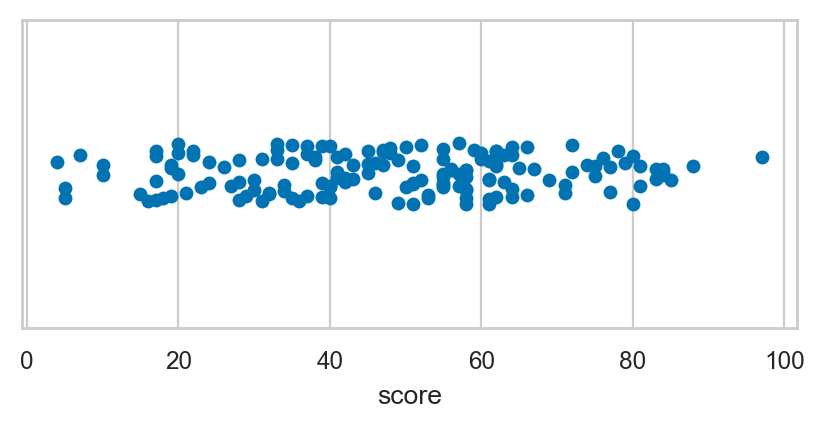

In [12]:
import pandas as pd
doctors = pd.read_csv("datasets/doctors.csv")

# a) Generate a strip plot
sns.stripplot(data=doctors, x="score");

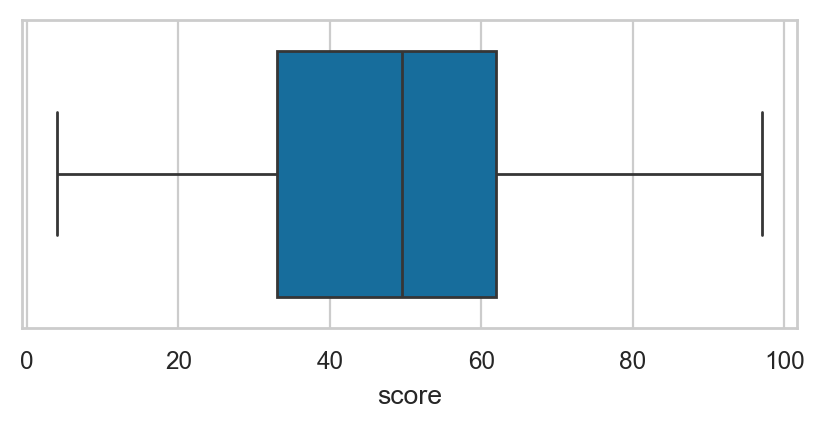

In [13]:
# b) Generate a box plot
sns.boxplot(data=doctors, x="score");

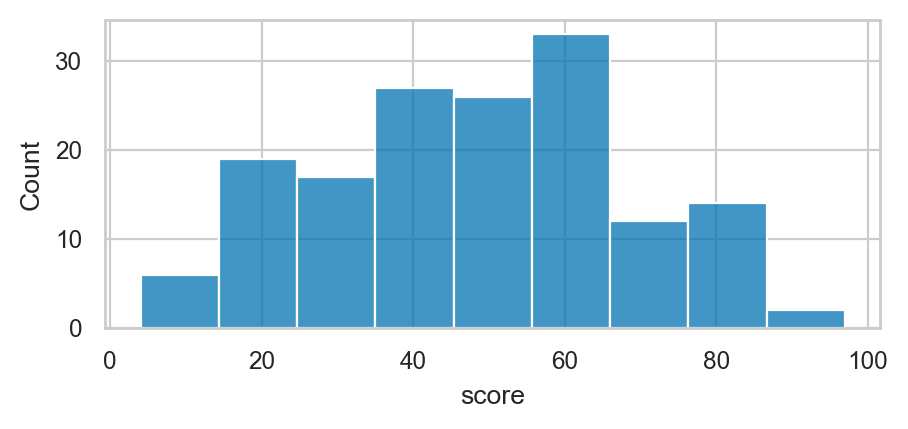

In [14]:
# c) Generate a histograms
sns.histplot(data=doctors, x="score");

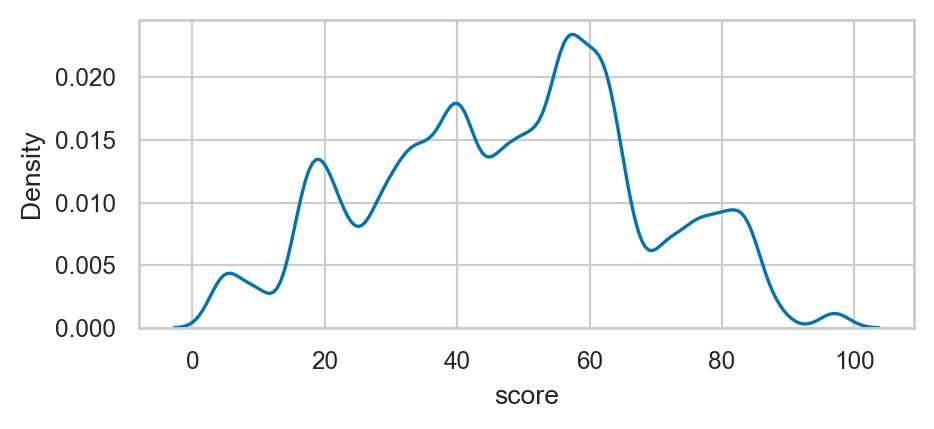

In [15]:
# d) Generate a KDE plot
sns.kdeplot(data=doctors, x="score", bw_adjust=0.3);

In [16]:
# e) Descriptive statistics
doctors["score"].describe()

count    156.00
mean      48.03
std       20.45
min        4.00
25%       33.00
50%       49.50
75%       62.00
max       97.00
Name: score, dtype: float64

### P1.7

The pandas convenience method `.describe()` allows us to compute several
key descriptive statistics in a single line of code. For example, the
code below computes the descriptive statistics for the variable `effort`
from the students dataset.

Can you write your own version of the `.describe()` method from scratch?

In [20]:
# b) Write a Python function that takes series as input
#    and produces the same output as the `.describe()` method.

def mydescribe(series):
    print("count", "\t", series.count())
    print("mean", "\t", series.mean().round(2))
    print("std", "\t", series.std().round(2))
    print("min", "\t", series.min().round(2))
    print("25%", "\t", series.quantile(0.25).round(2))
    print("50%", "\t", series.quantile(0.5).round(2))
    print("75%", "\t", series.quantile(0.75).round(2))
    print("max", "\t", series.max().round(2))

mydescribe(efforts)

count 	 15
mean 	 8.9
std 	 1.95
min 	 5.21
25% 	 7.76
50% 	 8.69
75% 	 10.35
max 	 12.0


### P1.8

Consider the sample $\mathbf{x} = (10,x_2,x_3)$. Find the values $x_2$
and $x_3$ such that $\overline{\mathbf{x}}=10$ and $s_{\mathbf{x}}=5$.


In [21]:
z = 5  # check answer 
xs = pd.Series([10, 10-z, 10+z])
xs.mean(), xs.std()

(10.0, 5.0)

### P1.9

The dataset
$[\mathbf{x}, \mathbf{y}] = [(2,2), (3,3), (4,3), (5,5), (6,4), (5,4), (7,6), (8,5)]$
consists of eight observations of the variables $x$ and $y$.  
**a)** Draw a scatter plot of the $(x,y)$ pairs.  
**b)** Compute $\overline{\mathbf{x}}$, $s_{\mathbf{x}}$, $\overline{\mathbf{y}}$, and
$s_{\mathbf{y}}$.  
**c)** Compute the covariance $\mathbf{cov}(\mathbf{x}, \mathbf{y})$.  
**d)** Compute the correlation coefficient $\mathbf{corr}(\mathbf{x}, \mathbf{y})$.  

Hint: You can use `pd.DataFrame([(2,2),(3,3),...],columns=["x","y"])`
to create a data frame object from the list of observations.

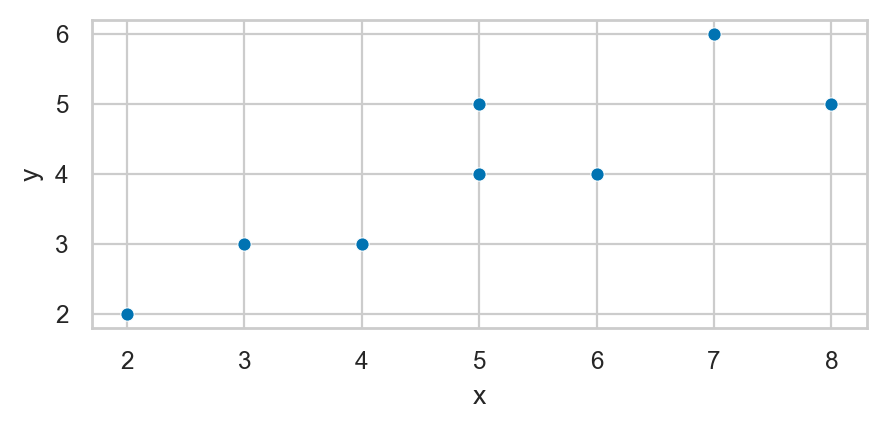

In [23]:
list_of_obs = [(2,2), (3,3), (4,3), (5,5), (6,4), (5,4), (7,6), (8,5)]
import pandas as pd
dfxy = pd.DataFrame(list_of_obs, columns=["x", "y"])

# a)
sns.scatterplot(data=dfxy, x="x", y="y");

In [24]:
# b)
dfxy["x"].mean(), dfxy["x"].std(), dfxy["y"].mean(), dfxy["y"].std()

(5.0, 2.0, 4.0, 1.3093073414159542)

In [25]:
# c)
dfxy.cov()

,x,y
x,4.00,2.29
y,2.29,1.71


In [26]:
# d)
dfxy.corr()

,x,y
x,1.00,0.87
y,0.87,1.00


We thus end up with the following answers:
**b)** $\overline{\mathbf{x}}=5$, $s_{\mathbf{x}}=2$,
$\overline{\mathbf{y}}=4$, $s_{\mathbf{y}}=1.31$,
**c)** $\mathbf{cov}(\mathbf{x}, \mathbf{y})=2.29$,
and **d)** $\mathbf{corr}(\mathbf{x}, \mathbf{y})=0.87$.

### P1.10

Consider the following Spear--Tukey box plot of the variable $\mathbf{z}$.

![](https://raw.githubusercontent.com/minireference/noBSstats/main/problems/src/attachments/descr_stats_z_from_boxplot.png)

Determine the values of the following descriptive statistics:
$\mathbf{med}(\mathbf{z})$, $\mathbf{min}(\mathbf{z})$,
$\mathbf{max}(\mathbf{z})$, $\mathbf{Q}_{1}(\mathbf{z})$,
$\mathbf{Q}_{2}(\mathbf{z})$,
$\mathbf{Q}_{3}(\mathbf{z})$, and
$\mathbf{IQR}(\mathbf{z})$, $\mathbf{range}(\mathbf{z})$.

The $\mathbf{z}$ statistics are:
$\mathbf{med}(\mathbf{z})=8$, $\mathbf{min}(\mathbf{z})=3$,
$\mathbf{max}(\mathbf{z})=15$,
$\mathbf{Q}_{1}(\mathbf{z})=5$,
$\mathbf{Q}_{2}(\mathbf{z})=8$,
$\mathbf{Q}_{3}(\mathbf{z})=10$,
$\mathbf{IQR}(\mathbf{z})=5$, $\mathbf{range}(\mathbf{z})=12$.

### P1.11

We want to summarize the dataset $\mathbf{x}_z = (1, 2, 3, 4, 5, z)$
by reporting a the mean $\mathbf{mean}(\mathbf{x})$
and the median $\mathbf{med}(\mathbf{x})$.

In [28]:
import pandas as pd
# a) z=10
xs10 = pd.Series([1, 2, 3, 4, 5, 10], name="x")
xs10.mean(), xs10.median()

(4.166666666666667, 3.5)

In [29]:
# b) z=25
xs25 = pd.Series([1, 2, 3, 4, 5, 25], name="x")
xs25.mean(), xs25.median()

(6.666666666666667, 3.5)

In [30]:
# c) z=50
xs50 = pd.Series([1, 2, 3, 4, 5, 50], name="x")
xs50.mean(), xs50.median()

(10.833333333333334, 3.5)

In [31]:
# d) z=100
xs100 = pd.Series([1, 2, 3, 4, 5, 100], name="x")
xs100.mean(), xs100.median()

(19.166666666666668, 3.5)

**e)** TODO

**f)** The median is a better summary statistic than the mean,
because it is not as affected by outliers.

### P1.12

We often encounter non-standard CSV data files. For example, the data
file [`datasets/formats/students_meta.csv`](https://noBSstats.com/datasets/formats/students_meta.csv)
contains metadata rows.

```
# title: Student's dataset with metadata rows
# description: A copy of students.csv with extra metadata at the top
# author: Ivan Savov
# date: 2026-03-25
student_ID,background,curriculum,effort,score
1,arts,debate,10.96,75
2,science,lecture,8.69,75
3,arts,debate,8.6,67
... 12 more lines ...
```

You'll get an error if you try loading this file using `pd.read_csv`
with no options. Consult the help docs for the function `pd.read_csv` to
find an option that skips the metadata rows, and load the data below
them.

Hint: Use `help(pd.read_csv)`, `pd.read_csv?`, or the online docs at [https://pandas.pydata.org/docs/](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).

Hint: There are at least two options you can use to skip the metadata rows.

One approach you can use is the add the option `comment="#"`,
which tells `pd.read_csv` to ignore all rows starting with `#`.
This is similar to how Python ignores comments.

In [33]:
students_meta = pd.read_csv("datasets/formats/students_meta.csv", comment="#")
students_meta.head()

,student_ID,background,curriculum,effort,score
0,1,arts,debate,10.96,75.0
1,2,science,lecture,8.69,75.0
2,3,arts,debate,8.60,67.0
3,4,arts,lecture,7.92,70.3
4,5,science,debate,9.90,76.1


Another approach is to use the option `skiprows=4`,
which tells `pd.read_csv` to skip the first four rows
and start reading the data file only at line `5`,
which is the header row.

In [34]:
students_meta2 = pd.read_csv("../../datasets/formats/students_meta.csv", skiprows=4)
students_meta2.head()

,student_ID,background,curriculum,effort,score
0,1,arts,debate,10.96,75.0
1,2,science,lecture,8.69,75.0
2,3,arts,debate,8.60,67.0
3,4,arts,lecture,7.92,70.3
4,5,science,debate,9.90,76.1


In [35]:
# Check that the data is the same as in `students.csv`
students = pd.read_csv("datasets/students.csv")
students_meta.equals(students), \
students_meta2.equals(students)

(True, True)

### P1.13


The data file
[`datasets/bpwide.csv`](https://noBSstats.com/datasets/bpwide.csv) is in
wide format with columns `patient`, `sex`, `agegrp`, `bp_before`, and
`bp_after`. The last two columns contain blood pressure measurements
taken before and after an intervention. This file is not tidy data since
there are two observations per row. Convert the data to tidy data (long
format), with the columns `patient`, `sex`, `agegrp`, `when`, and `bp`,
where the variable `when` encodes when the measurement was taken
(`Before` or `After`), and `bp` contains the corresponding measurement.

The first three columns contain identifying variables for a particular individual
so we'll use them as `id_vars`.
We want the name column to be `when` so we set `var_name="when"`,
and the value column to be `bp` so we set `value_name="bp"`.

In [37]:
import pandas as pd
bpwide = pd.read_csv("datasets/bpwide.csv")

bplong = bpwide.melt(id_vars=["patient", "sex", "agegrp"],
                     var_name="when", value_name="bp")
bplong.head(3)

,patient,sex,agegrp,when,bp
0,1,Male,30-45,bp_before,143
1,2,Male,30-45,bp_before,163
2,3,Male,30-45,bp_before,153


In [38]:
# Replace the `when` column values
replacements = {"bp_before":"Before", "bp_after":"After"}
bplong["when"] = bplong["when"].replace(replacements)
bplong.head(3)

,patient,sex,agegrp,when,bp
0,1,Male,30-45,Before,143
1,2,Male,30-45,Before,163
2,3,Male,30-45,Before,153


In [39]:
# Sort by patient number
bplong = bplong.sort_values(by=["patient"]).reset_index(drop=True)
bplong.head(3)

,patient,sex,agegrp,when,bp
0,1,Male,30-45,Before,143
1,1,Male,30-45,After,153
2,2,Male,30-45,Before,163


In [40]:
# Sort by patient and always show bp_before before bp_after
bplong = bplong.sort_values(by=["patient","when"], ascending=(True,False)) \
               .reset_index(drop=True)

# Check that our `bplong` matches the expected `bplong.csv`
bplong_expected = pd.read_csv("datasets/bplong.csv")
bplong.equals(bplong_expected)

True

### P1.14

The data file
[`datasets/kombuchapop.csv`](https://noBSstats.com/datasets/kombuchapop.csv)
contains the volume measurements from all 1000 bottles in the kombucha
batches 55 and 56. This is a *census* of the entire population. We'll
generate a random sample from the batch 55 population to investigate
whether random samples really are representative of the population, as
we hope they are.  
**a)** Compute the population mean and population standard deviation.   
**b)** Draw a random sample $\mathbf{k} = \texttt{ksample}$ of size $n=30$ from the
population and compute the sample mean $\overline{\mathbf{k}}$ and the
sample standard deviation $s_{\mathbf{k}}$.  
**c)** Draw 5000 samples of size
$n=30$ from the population compute the sample mean
$\overline{\mathbf{k}}$ from each of these samples, and plot a histogram
of the 5000 sample means
$[\overline{\mathbf{k}}_1, \overline{\mathbf{k}}_2, \ldots, \overline{\mathbf{k}}_{5000}]$.  
**d)** Based on the histogram, what can you say about the random sampling
approach? Does random sampling produce representative samples?

In [42]:
import pandas as pd
kombuchapop = pd.read_csv("datasets/kombuchapop.csv")
kpopulation = kombuchapop[kombuchapop["batch"]==55]["volume"]

# a) Compute the population mean and standard deviation
kpopulation.mean(), kpopulation.std()

(1000.14613, 9.969846556665928)

In [44]:
# set the random seed to a particular value to get a reproducible result
np.random.seed(42)

# b) Draw a random sample of size n=30 from `kpopulation`
#    and compute the sample mean and standard deviation.
ksample = kpopulation.sample(30)
ksample.mean(), ksample.std()

(1003.0413333333333, 9.588299526823922)

In [45]:
# ALT. We can also use `np.random.choice` to draw a random sample
np.random.seed(42)
ksample = np.random.choice(kpopulation, size=30, replace=False)
ksample.mean(), ksample.std()

(1003.0413333333333, 9.427140157839782)

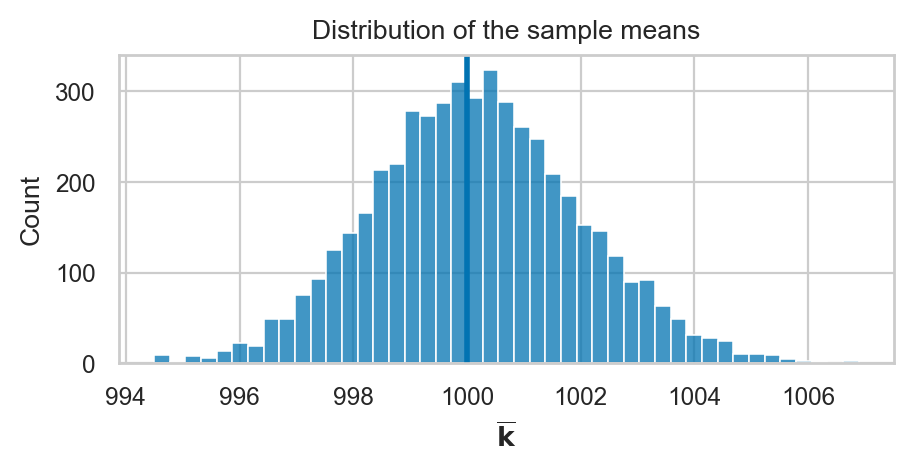

In [47]:
# set the random seed to get a reproducible result
np.random.seed(42)

# c) Draw 5000 samples of size n=30 from `kpopulation`,
#    compute the sample mean from each of these samples,
#    and plot a histogram of the 5000 sample means.
kbars = []
for i in range(5000):
    ksample = kpopulation.sample(30)
    kbar = ksample.mean()
    kbars.append(kbar)

ax = sns.histplot(x=kbars);
ax.set_xlabel(r"$\overline{\mathbf{k}}$")
ax.set_title("Distribution of the sample means")
ax.axvline(1000, linewidth=2);

As you can see, we can't *guarantee* that random sampling will produce a
representative sample—once in a while the sample mean will be very far
away the population mean.

### P1.15

Your friend Ben has written the following function for generating a
random sample of size `n` from a given `population`.

In [48]:
import numpy as np
from numpy.random import choice

def get_sample(population, n):
    N = len(population)
    nmore, nless = N//2, N - N//2
    ws = np.concat([5*np.ones(nmore), np.ones(nless)])
    p = ws / np.sum(ws)
    sample = choice(population, size=n, replace=False, p=p)
    return sample

Use this function to generate a few samples of size $n=30$ from Batch 55
of the kombucha population dataset
[`datasets/kombuchapop.csv`](https://noBSstats.com/datasets/kombuchapop.csv).
Compare the sample means to the population mean. What can you say about
the the samples produced by Ben's sampling function?

In [50]:
import pandas as pd
kombuchapop = pd.read_csv("datasets/kombuchapop.csv")
kpopulation = kombuchapop[kombuchapop["batch"]==55]["volume"]

# The population mean
print("Population mean is", kpopulation.mean().round(2))

Population mean is 1000.15


Let's generate 10 samples using Ben's sampling funcrtion.

In [51]:
# set the random seed to get a reproducible result
np.random.seed(42)

for i in range(10):
    ksample = get_sample(kpopulation, 30)
    print(ksample.mean().round(2), end="\t")

993.63	995.04	994.26	994.09	993.74	994.44	994.0	995.93	998.49	993.52	

Ben's sampling function chooses values from the first half of the
population five times more often than values in the second half of the
population. Since the kombucha population data is sorted in increasing
order, the samples we obtain are biased samples. The means computed from
these samples systematically underestimate the population mean.

### P1.16

The dataset
[`datasets/howell30.csv`](https://noBSstats.com/datasets/howell30.csv)
contains `sex`, `age`, `weight`, and `height` information for 298
individuals.

In [52]:
howell30 = pd.read_csv("datasets/howell30.csv")
n = howell30.shape[0]
print("number of individuals:", n)
howell30.head()

number of individuals: 298


,caseid,sex,age,weight,height
0,9,M,27.6,55.5,168.9
1,10,F,19.5,34.9,148.0
2,15,F,21.1,48.4,150.5
3,20,M,13.1,23.2,127.6
4,21,F,8.8,15.8,110.2


Suppose you're preparing to run a statistical experiment,
and you want to randomly assign half the individuals to Group A (the
intervention group), and the remaining individuals to Group B (the
control group).  

**a)** Write the Python code that performs the random assignment, then compare
the average `age` in the two groups. Did the random assignment produce
two groups of equal size? Did the random assignment produce balanced
groups with similar average age?   

In [53]:
# set the random seed to get a reproducible result
np.random.seed(46)

# Generate n coin tosses (heads=True, tails=False)
maskA = np.random.choice([True,False], size=n)

# Select the two groups using mask and not-mask
groupA = howell30.loc[maskA]
groupB = howell30.loc[~maskA]

print("group sizes:", len(groupA), len(groupB))
print("age means:", groupA["age"].mean().round(2), groupB["age"].mean().round(2))

group sizes: 148 150
age means: 14.2 13.66


**b)** Repeat the random assignment procedure
3000 times and calculate the 3000 differences between average age in the
two groups. Plot a histogram of the mean age differences. Does random
assignment produce balanced groups?  

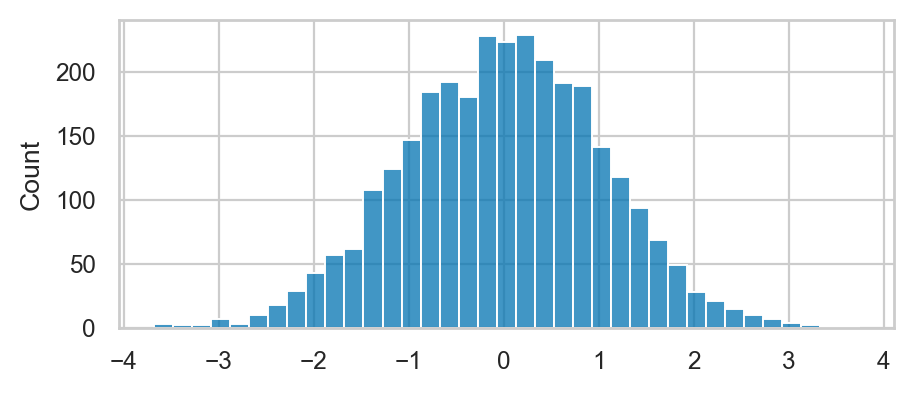

In [54]:
# set the random seed to get a reproducible result
np.random.seed(47)

mean_diffs = []
for i in range(3000):
    mask = np.random.choice([True,False], size=n)
    groupA = howell30.loc[mask]
    groupB = howell30.loc[~mask]
    mean_diff = groupA["age"].mean() - groupB["age"].mean()
    mean_diffs.append(mean_diff)

sns.histplot(x=mean_diffs);

**c)** Estimate the proportion of the 3000
assignments that led to groups where the average age differs by more
than two years. Does the random assignment procedure *guarantee* the two
groups will be balanced?

In [55]:
big_diffs = [d for d in mean_diffs if abs(d) > 2]
len(big_diffs) / len(mean_diffs)

0.056

### P1.17

Load the doctors dataset
([`datasets/doctors.csv`](https://noBSstats.com/datasets/doctors.csv))
and compute the descriptive statistics for the categorical variables
`loc` and `work`.   
**a)** The conditional relative frequency
$\mathbf{relfreq}_{\texttt{rur}|\texttt{cli}}(\texttt{loc}, \texttt{work})$.  
**b)** The conditional relative frequency
$\mathbf{relfreq}_{\texttt{cli}|\texttt{rur}}(\texttt{loc}, \texttt{work})$.


Hint: Use the `pd.crosstab` function with the `normalize` option.

In [57]:
doctors = pd.read_csv("datasets/doctors.csv")

# a) Conditional relative frequency rur | cli
pd.crosstab(index=doctors["loc"], columns=doctors["work"],
            margins=True, normalize="columns")

work,cli,eld,hos,All
loc,,,,
rur,0.36,0.19,0.21,0.29
urb,0.64,0.81,0.79,0.71


In [58]:
# b) Conditional relative frequency cli | rur
pd.crosstab(index=doctors["loc"], columns=doctors["work"],
            normalize="index", margins=True)

work,cli,eld,hos
loc,,,
rur,0.70,0.11,0.20
urb,0.51,0.19,0.30
All,0.56,0.17,0.27


The answers are: 
$\mathbf{relfreq}_{\texttt{rur}|\texttt{cli}}=0.36$ and
$\mathbf{relfreq}_{\texttt{cli}|\texttt{rur}}=0.7$.

### P1.18

The dataset
([`datasets/faithful.csv`](https://noBSstats.com/datasets/faithful.csv))
contains data about the eruptions of the Old Faithful geyser in
Yellowstone National Park. We'll focus on the variable `duration`, which
represents how long each eruption lasted.  
**a)** Compute the mean and the standard deviation of the variable `duration`.  
**b)** Generate a box plot of the variable `duration`.  
**c)** Using the information from the previous two answers,
what do you think the `duration` data looks like?   
**d)** Generate a histogram of the variable `duration`. What does
the histogram show that the descriptive statistics didn't show?

In [59]:
faithful = pd.read_csv("datasets/faithful.csv")
faithful.head(3)



,duration,waiting
0,3.60,79
1,1.80,54
2,3.33,74


In [60]:
# a) 
faithful["duration"].mean(), faithful["duration"].std()

(3.4877830882352936, 1.141371251105208)

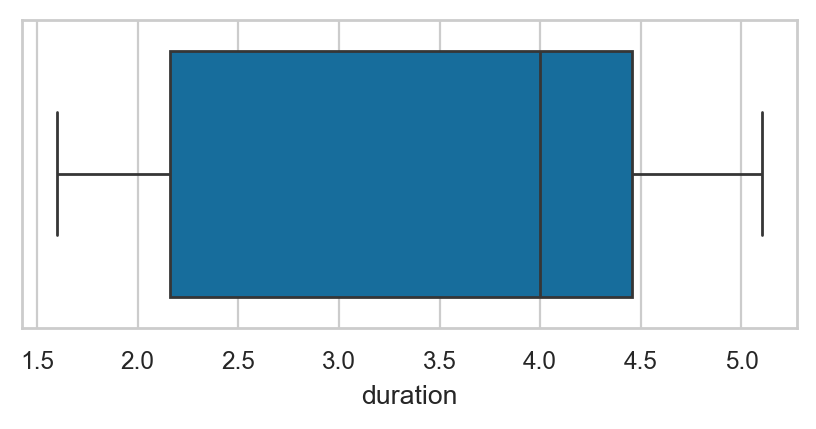

In [61]:
# b)
sns.boxplot(data=faithful, x="duration");

**c)** We know the center of the dataset is around 3.5 or 4,
and it has a fairly wide dispersion.
We might assume most of the data is near the mean.

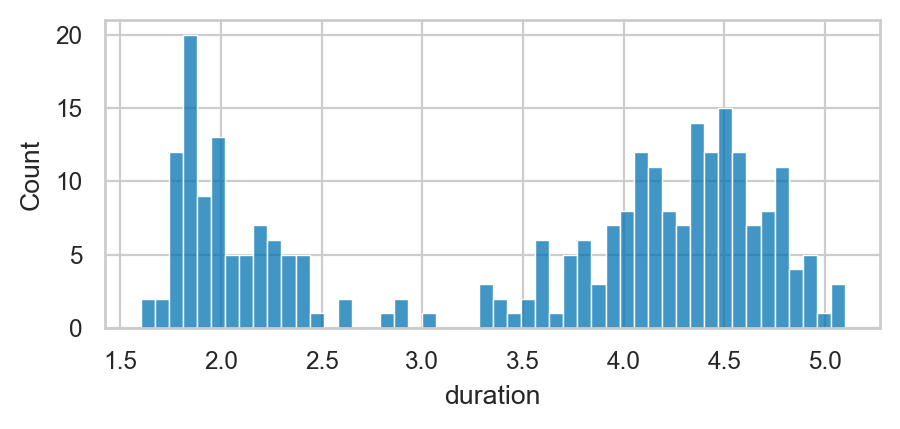

In [62]:
# d)
sns.histplot(data=faithful, x="duration", bins=50);

**d)** The descriptive statistics and the box plot hide the fact that the
`duration` data is bimodal, which we can see in the histogram.

### P1.19 NEW



In [63]:
# a)
import seaborn as sns
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [64]:
# b)
penguins["body_mass_g"].mean()

4201.754385964912

In [65]:
# c)
penguins.groupby("species")["body_mass_g"].mean()

species
Adelie       3700.66
Chinstrap    3733.09
Gentoo       5076.02
Name: body_mass_g, dtype: float64

In [66]:
# d)
sns.get_dataset_names()

URLError: <urlopen error [Errno 8] nodename nor servname provided, or not known>